In [13]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [14]:
EP = [ 1.98, 2.31, 3.29, 3.56, 1.23, 1.57, 2.05, 0.66, 0.31, 2.82, 0.13, 3.15, 2.72, 2.31, 1.92, 1.56, 0.94, 2.27, 3.17, 2.36 ]
CF = [ 1.87, 2.20, 3.15, 3.42, 1.10, 1.41, 1.84, 0.68, 0.27, 2.80, 0.14, 3.20, 2.70, 2.43, 1.78, 1.53, 0.84, 2.21, 3.10, 2.34 ]

EPn = np.array(EP)
EPm = EPn.mean()
EPv = EPn.var()

CFn = np.array(CF)
CFm = CFn.mean()
CFv = CFn.var()

print(EPv, CFv)

0.93113475 0.9232447500000001


18.622695 18.481445000000004


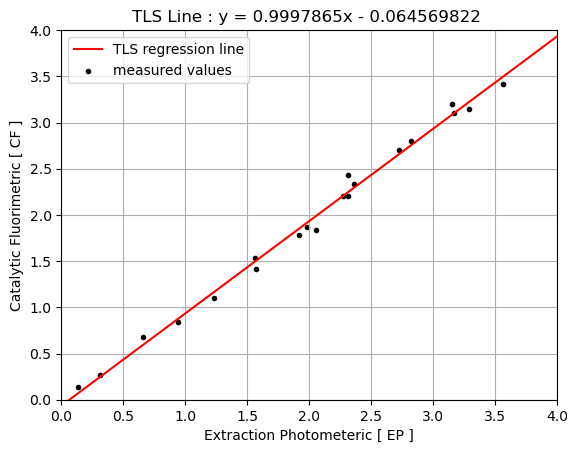

alpha = 0.9997865654468353 beta = -0.06456982265809641


In [19]:
# Covariance Calculation : 

covariance = 0 

for i in range(20) :
    covariance += (EPn[i] - EPm)*(CF[i] - CFm)

print(20*EPv, covariance)
# alpha = covariance/(20*EPv)
alpha = ((CFv-EPv) + math.sqrt((CFv-EPv)**2 + 4*covariance*covariance))/(2*covariance)
beta  = CFm - alpha*EPm

n = np.linspace(0, 4, 30)
plt.plot(n, alpha*n + beta, color = 'red')
plt.scatter(EPn, CFn, marker = '.',color = 'black')
plt.style.use('tableau-colorblind10')
plt.xlabel("Extraction Photometeric [ EP ]")
plt.ylabel("Catalytic Fluorimetric [ CF ]")
plt.title("TLS Line : y = 0.9997865x - 0.064569822 ")
plt.xlim(0, 4.0)
plt.ylim(0, 4.0)
plt.legend(['TLS regression line', 'measured values'])
plt.grid()
plt.show()

print('alpha =', alpha, 'beta =', beta)

In [ ]:
Evarr = 0
for i in range(20) :
    k = (CFn[i] - alpha*EPn[i] - beta)
    Evarr = Evarr + k*k
    

Evarr = Evarr/18
Avarr = Evarr/(20*EPv)
Bvarr = 0

for x in EP :
    Bvarr = Bvarr + x**2

Bvarr = Bvarr*Evarr/(20*20*EPv)

print(Evarr, Avarr, Bvarr)

Alower_limit = alpha - 2.101*(Avarr**0.5)
Aupper_limit = alpha + 2.101*(Avarr**0.5)

Blower_limit = beta - 2.101*(Bvarr**0.5)
Bupper_limit = beta + 2.101*(Bvarr**0.5)

print('alpha confidence interval : [',Alower_limit, Aupper_limit ,']')
print('beta confidence interval : [',Blower_limit, Bupper_limit ,']')